# Caderno 8 - Comparação de ranking de sistemas de busca gerado por diversos qrels

## 1. Parâmetros

In [1]:
PASTA_DOCS_QRELS = './dados/outputs/0 - qrel - docs - query - raw_human_eval/'
PASTA_QRELS_LLMS = './dados/outputs/4 - qrel llm/'
PASTA_RUNS = './dados/outputs/7 - runs/'

ARQUIVO_QRELS = f'{PASTA_DOCS_QRELS}/qrel.csv'

## 2. Carrega todos os qrels

In [2]:
# Carrega todos os qrels de LLMs
from pathlib import Path
import pandas as pd

qrels = {}

# Carrega o qrels humano
qrels['human'] = pd.read_csv(ARQUIVO_QRELS)

# Percorre todos os arquivos .csv da pasta
PASTA_QRELS_LLMS = Path(PASTA_QRELS_LLMS)
for arquivo in PASTA_QRELS_LLMS.glob("*.csv"):
    # Nome do arquivo sem extensão
    nome_qrels = arquivo.stem
    
    # Lê o CSV
    df = pd.read_csv(arquivo)
    
    # Salva no dicionário
    qrels[nome_qrels] = df

print(f"{len(qrels)} arquivos carregados.")

C:\Users\caris\anaconda3\Lib\site-packages\numpy\__init__.py:127: UserWarning: mkl-service package failed to import, therefore Intel(R) MKL initialization ensuring its correct out-of-the box operation under condition when Gnu OpenMP had already been loaded by Python process is not assured. Please install mkl-service package, see http://github.com/IntelPython/mkl-service
  from . import _distributor_init


7 arquivos carregados.


## 3. Carrega todos os runs

In [3]:
runs = {}

# Percorre todos os arquivos .csv da pasta
PASTA_RUNS = Path(PASTA_RUNS)
for arquivo in PASTA_RUNS.glob("*.csv"):
    # Nome do arquivo sem extensão
    nome_run = arquivo.stem
    
    # Lê o CSV
    df = pd.read_csv(arquivo)
    
    # Salva no dicionário
    runs[nome_run] = df

print(f"{len(runs)} arquivos carregados.")

15 arquivos carregados.


In [14]:
# Exporta todos os runs em um único df, caso seja necessário.
import pandas as pd

dfs = []

for modelo, df in runs.items():
    df_copy = df.copy()
    df_copy["MODELO"] = modelo
    dfs.append(df_copy)

# Concatena tudo
df_final = pd.concat(dfs, ignore_index=True)

# Opcional: colocar MODELO como primeira coluna
cols = ["MODELO"] + [c for c in df_final.columns if c != "MODELO"]
df_final = df_final[cols]

# Salva
#df_final.to_csv("df_todos_runs.csv", index=False)

#print("CSV gerado com sucesso.")

CSV gerado com sucesso.


## 4. Gera métricas para todos os runs usando todos os pares de qrels

In [4]:
from metricas import metricas

results = []

for qrels_name, df_qrels in qrels.items():
    for run_name, df_run in runs.items():
        
        # Aqui você calcula as métricas
        df_resultados = metricas(df_run, df_qrels, aproximacao_trec_eval=True, k=[5, 10])

        metricas_disponiveis = ['nDCG@5', 'P@5', 'R@5', 'MRR@5', 'nDCG@10', 'P@10', 'R@10', 'MRR@10']
        for metrica_name in metricas_disponiveis:
            results.append({
                "qrels": qrels_name,
                "run": run_name,
                "metric": metrica_name,
                "value": df_resultados[metrica_name].mean(),
                "std": df_resultados[metrica_name].std()
            })

df_metricas = pd.DataFrame(results)

In [20]:
x = df_metricas[df_metricas.qrels=='human']
x = x[x.metric == 'nDCG@10']
#x = x[x.run == 'run_bm25_0.82_0.68_texto']
x

,qrels,run,metric,value,std
4,human,run_bm25_0.82_0.68_assunto_e_texto,nDCG@10,0.355539,0.333015
12,human,run_bm25_0.82_0.68_texto,nDCG@10,0.326307,0.314757
20,human,run_bm25_0.9_0.4_assunto_e_texto,nDCG@10,0.379164,0.324951
28,human,run_bm25_0.9_0.4_texto,nDCG@10,0.352212,0.313702
36,human,run_bm25_1_0.3_assunto_e_texto,nDCG@10,0.394779,0.320039
44,human,run_bm25_1_0.3_texto,nDCG@10,0.363738,0.314334
52,human,run_bm25_1_0.9_assunto_e_texto,nDCG@10,0.336725,0.325603
60,human,run_bm25_1_0.9_texto,nDCG@10,0.296741,0.313840
68,human,run_bm25_1_0.9_texto_gemini-embedding-001,nDCG@10,0.334523,0.300151
76,human,run_bm25_1_0.9_texto_text-embedding-3-small,nDCG@10,0.306353,0.311161


## 5. Calcula a correlação do ranking dos sistemas usando Kendall Tau e coeficiente de Spearman

In [6]:
from scipy.stats import kendalltau, spearmanr
import pandas as pd

resultados_correlacao = []

metricas_disponiveis = df_metricas["metric"].unique()

for metrica in metricas_disponiveis:
    # Filtra apenas essa métrica
    df_metrica = df_metricas[df_metricas["metric"] == metrica]
    
    # Pivot: linhas = runs, colunas = qrels
    pivot = df_metrica.pivot(
        index="run",
        columns="qrels",
        values="value"
    )
       
    # Ranking induzido pelo qrels humano
    valores_human = pivot["human"]
    
    for qrels_name in pivot.columns:
        if qrels_name == "human":
            continue
        
        valores_outro = pivot[qrels_name]
        
        # Calcula Kendall tau-b
        tau, p_tau = kendalltau(valores_human, valores_outro)
        
        # Calcula Spearman rho
        rho, p_rho = spearmanr(valores_human, valores_outro)
        
        resultados_correlacao.append({
            "metric": metrica,
            "qrels_comparado": qrels_name,
            "kendall_tau": tau,
            "kendall_pvalue": p_tau,
            "spearman_rho": rho,
            "spearman_pvalue": p_rho
        })

df_correlacoes = pd.DataFrame(resultados_correlacao)

df_correlacoes.sort_values(["metric", "kendall_tau"], ascending=[True, False], inplace=True)

df_correlacoes.reset_index(drop=True, inplace=True)

df_correlacoes

,metric,qrels_comparado,kendall_tau,kendall_pvalue,spearman_rho,spearman_pvalue
0,MRR@10,qrel_gpt-5-mini-2025-08-07_cot,0.866667,1.543396e-07,0.957143,2.273675e-08
1,MRR@10,qrel_gpt-5-mini-2025-08-07_simple,0.866667,1.543396e-07,0.957143,2.273675e-08
2,MRR@10,qrel_sabiazinho-4-2026-01-06_cot,0.866667,1.543396e-07,0.957143,2.273675e-08
3,MRR@10,qrel_sabiazinho-4-2026-01-06_simple,0.866667,1.543396e-07,0.957143,2.273675e-08
4,MRR@10,qrel_deepseek-chat_cot,0.847619,4.073461e-07,0.953571,3.792440e-08
5,MRR@10,qrel_deepseek-chat_simple,0.828571,9.951377e-07,0.946429,9.447939e-08
6,MRR@5,qrel_gpt-5-mini-2025-08-07_cot,0.866667,1.543396e-07,0.957143,2.273675e-08
7,MRR@5,qrel_gpt-5-mini-2025-08-07_simple,0.866667,1.543396e-07,0.957143,2.273675e-08
8,MRR@5,qrel_sabiazinho-4-2026-01-06_cot,0.866667,1.543396e-07,0.957143,2.273675e-08
9,MRR@5,qrel_sabiazinho-4-2026-01-06_simple,0.866667,1.543396e-07,0.957143,2.273675e-08


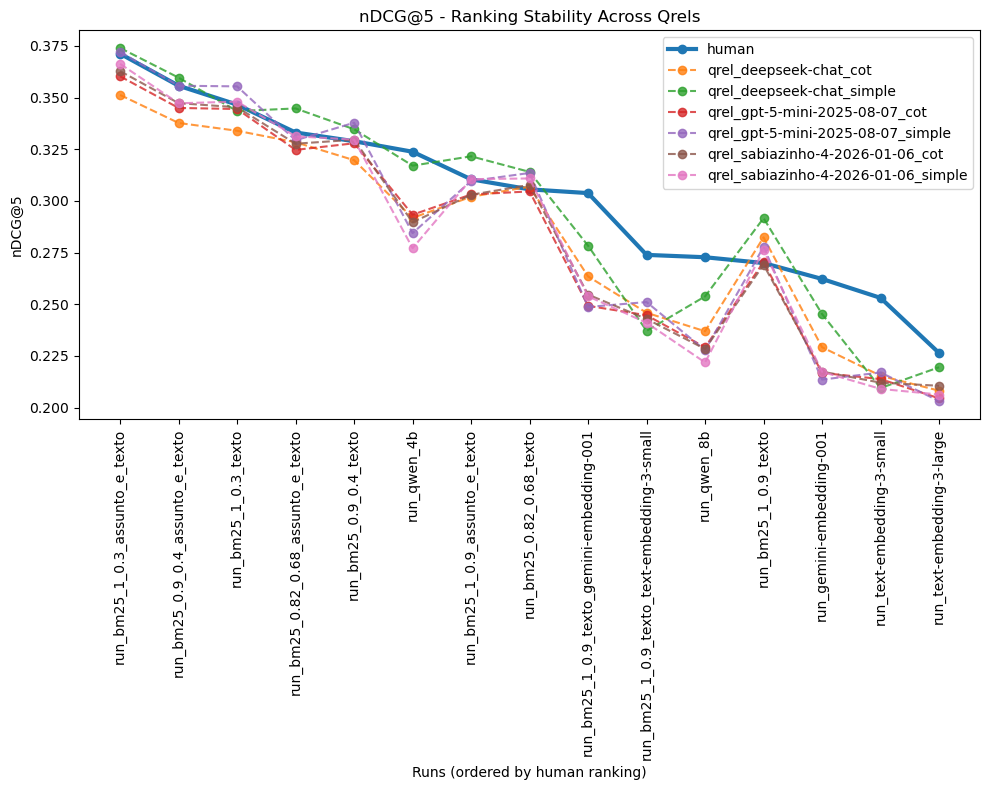

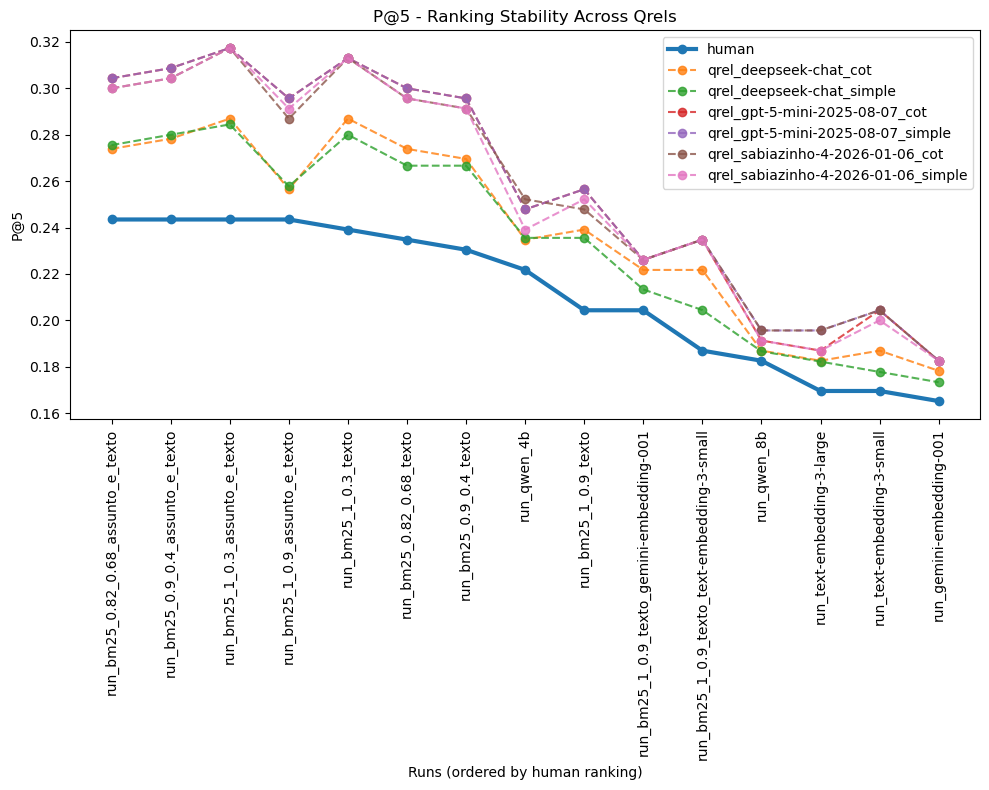

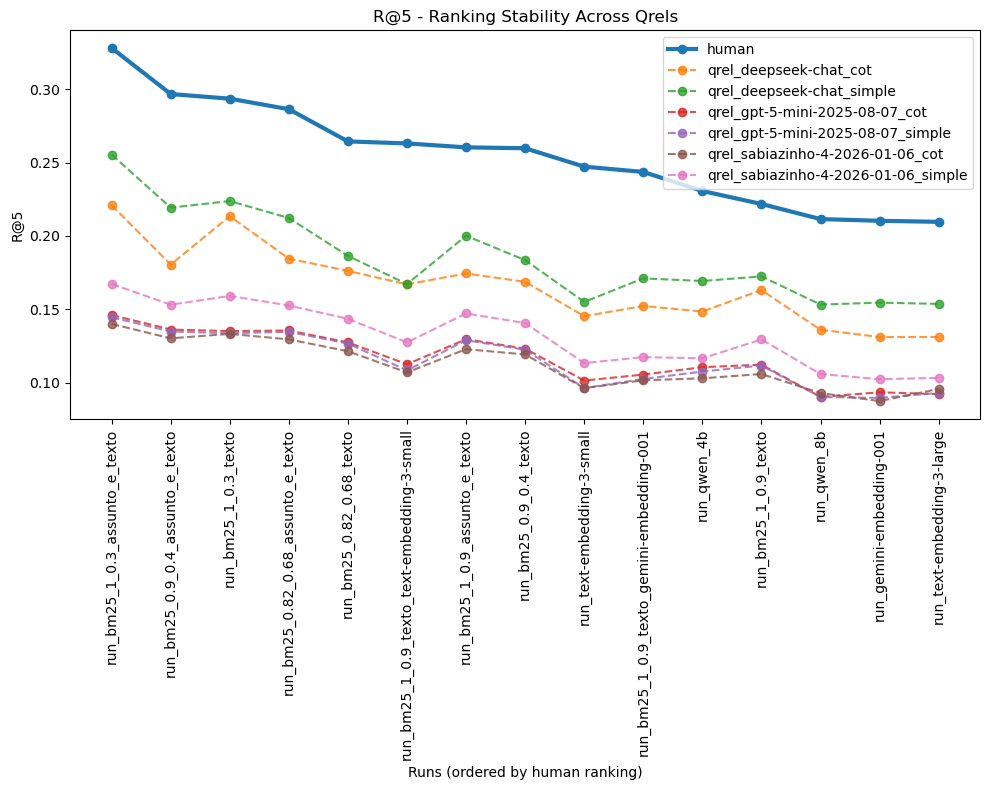

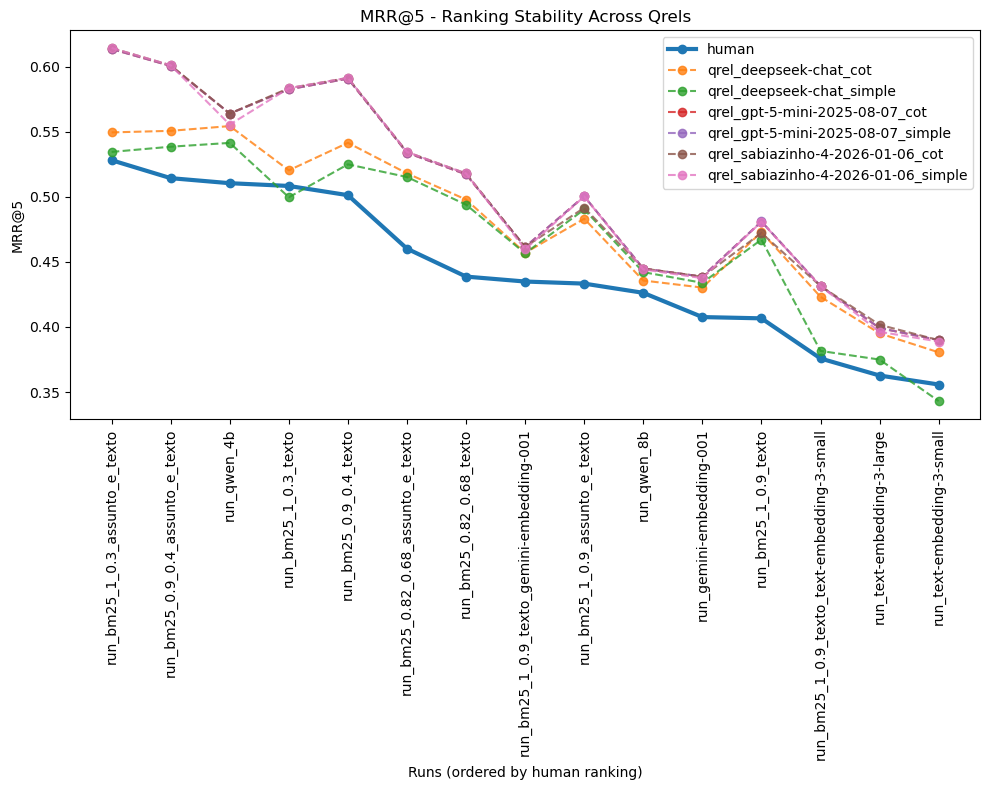

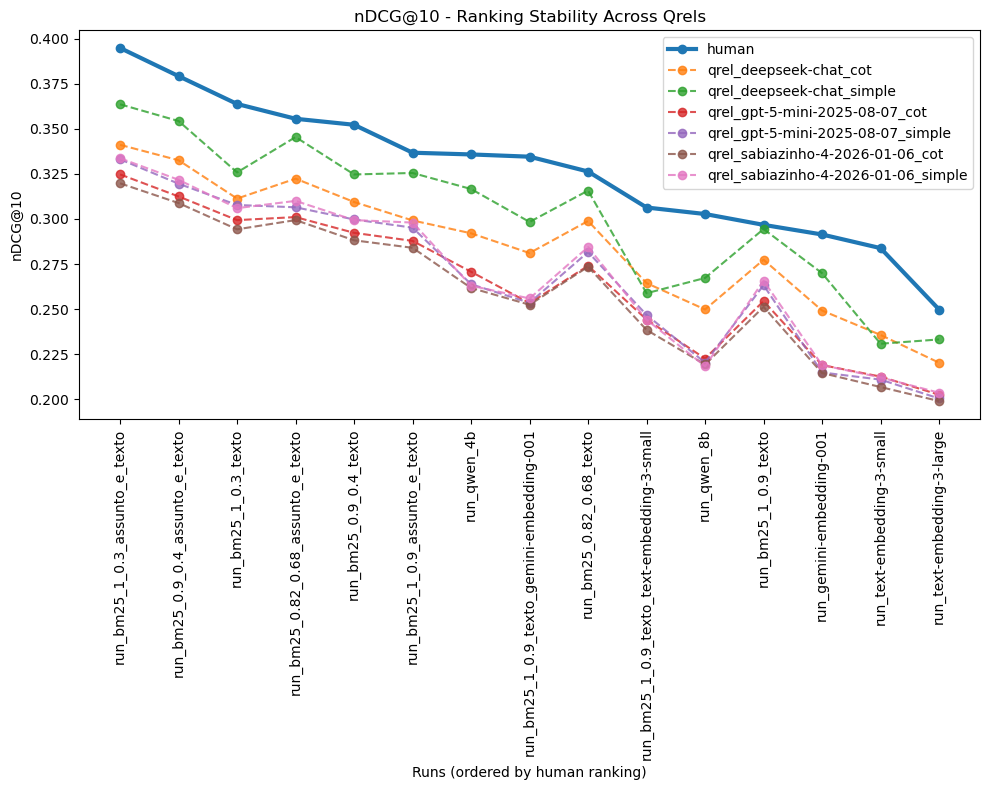

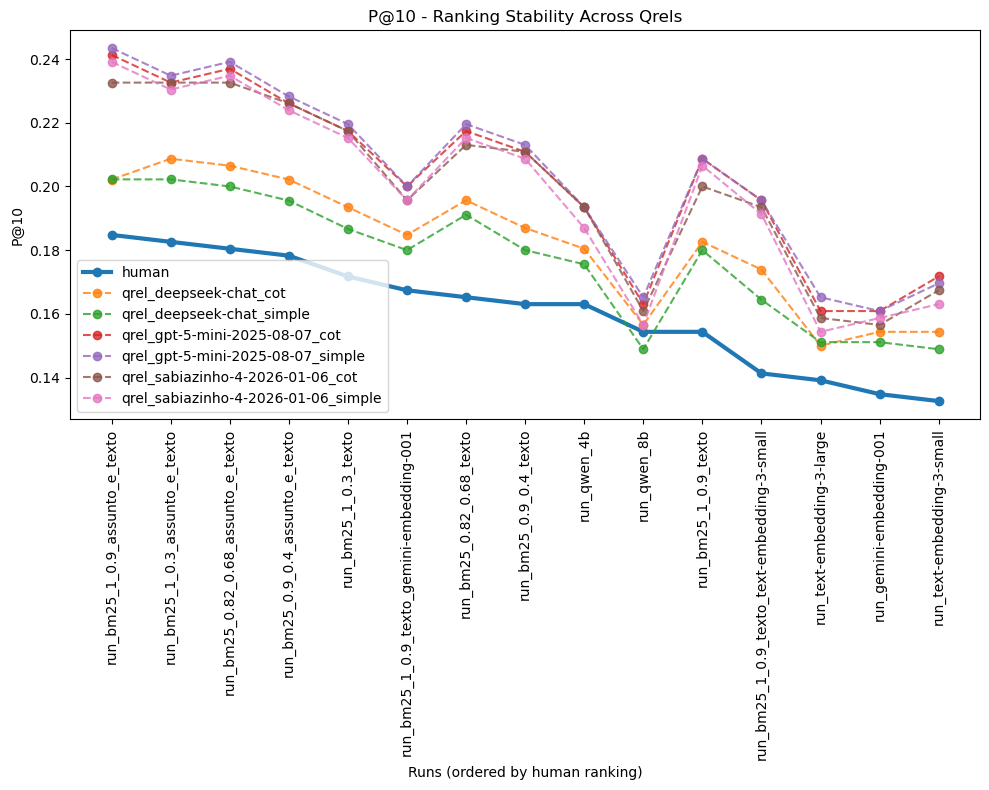

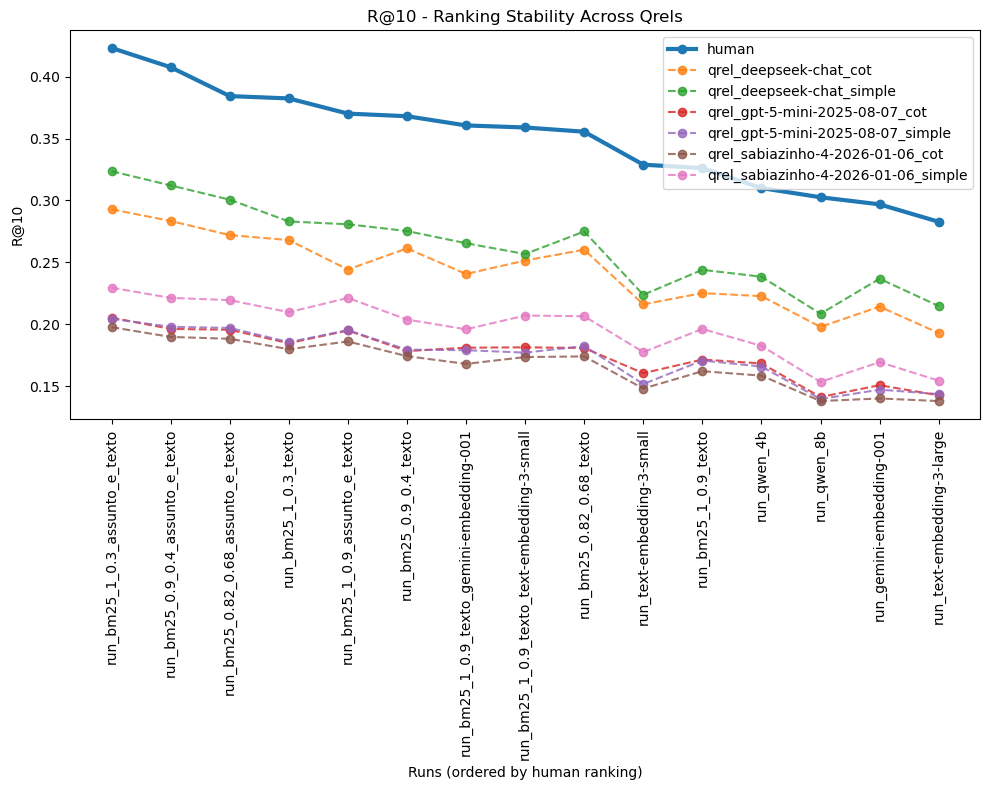

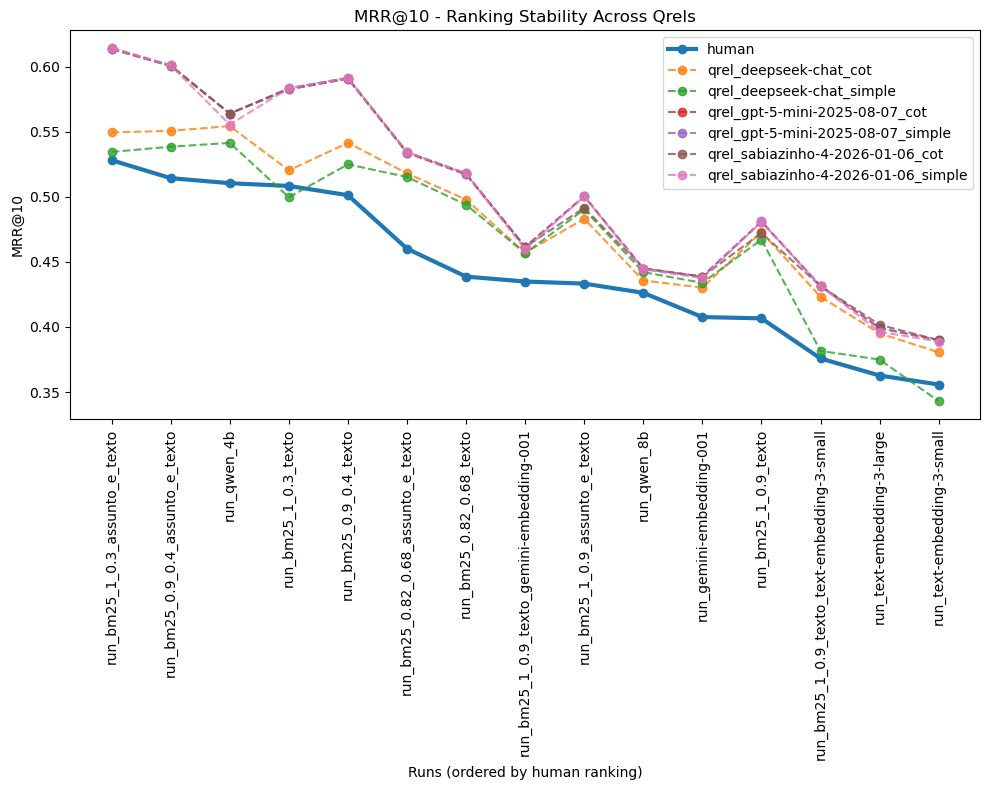

In [7]:
import matplotlib.pyplot as plt

metricas_disponiveis = df_metricas["metric"].unique()

for metrica in metricas_disponiveis:
    df_metrica = df_metricas[df_metricas["metric"] == metrica]
    
    # Pivot para facilitar acesso
    pivot = df_metrica.pivot(
        index="run",
        columns="qrels",
        values="value"
    )
       
    # Ordena runs pelo desempenho humano (decrescente)
    pivot = pivot.sort_values("human", ascending=False)
    
    runs_ordenados = pivot.index.tolist()
    x = range(len(runs_ordenados))
    
    plt.figure(figsize=(10, 8))
    
    # ===== Plot humano =====
    plt.plot(
        x,
        pivot["human"],
        marker="o",
        linewidth=3,
        label="human"
    )
    
    # ===== Plot outros qrels =====
    for qrels_name in pivot.columns:
        if qrels_name == "human":
            continue
        
        plt.plot(
            x,
            pivot[qrels_name],
            marker="o",
            linestyle="--",
            alpha=0.8,
            label=qrels_name
        )
    
    # Configurações do gráfico
    plt.xticks(x, runs_ordenados, rotation=90)
    plt.xlabel("Runs (ordered by human ranking)")
    plt.ylabel(metrica)
    plt.title(f"{metrica} - Ranking Stability Across Qrels")
    plt.legend()
    plt.tight_layout()
    
    plt.show()